<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Полезные-ссылки:" data-toc-modified-id="Полезные-ссылки:-0.0.1"><span class="toc-item-num">0.0.1&nbsp;&nbsp;</span><font color="orange">Полезные ссылки:</font></a></span></li></ul></li><li><span><a href="#Общее-впечатление" data-toc-modified-id="Общее-впечатление-0.1"><span class="toc-item-num">0.1&nbsp;&nbsp;</span><font color="orange">Общее впечатление</font></a></span></li><li><span><a href="#Общее-впечатление-(ревью-2)" data-toc-modified-id="Общее-впечатление-(ревью-2)-0.2"><span class="toc-item-num">0.2&nbsp;&nbsp;</span><font color="orange">Общее впечатление (ревью 2)</font></a></span></li></ul></li><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span><ul class="toc-item"><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Вывод:-декомпозиция-временного-ряда" data-toc-modified-id="Вывод:-декомпозиция-временного-ряда-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Вывод: декомпозиция временного ряда</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span><ul class="toc-item"><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Тестирование</a></span></li></ul></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Общий вывод</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings('ignore')

# Для временных рядов
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Настройка отображения графиков
plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Загрузка данных
data = pd.read_csv('/datasets/taxi.csv', index_col='datetime', parse_dates=True)

# Отсортируем данные по времени
data = data.sort_index()

# Выведем первые 5 строк
display(data.head())

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [3]:
# Проверка на пропуски
print("Пропуски в данных (до ресемплирования):")
print(data.isnull().sum())

# Проверка типов данных
print("\nТипы данных:")
print(data.dtypes)

# Общая информация
print("\nОбщая информация о данных:")
data.info()

Пропуски в данных (до ресемплирования):
num_orders    0
dtype: int64

Типы данных:
num_orders    int64
dtype: object

Общая информация о данных:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [4]:
# Ресемплирование данных по одному часу
data_hourly = data.resample('1H').sum()

# Выведем первые 5 строк
display(data_hourly.head())

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


## Анализ

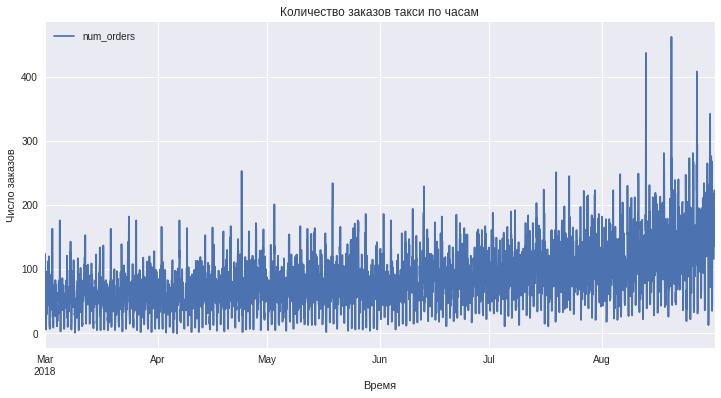

In [5]:
# Построение графика временного ряда
data_hourly.plot()
plt.title('Количество заказов такси по часам')
plt.ylabel('Число заказов')
plt.xlabel('Время')
plt.show()

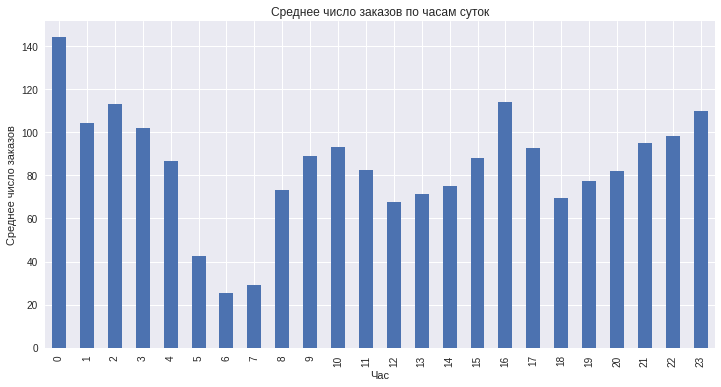

In [6]:
# Добавляем час суток
data_hourly['hour'] = data_hourly.index.hour

# Группируем по часу и считаем среднее количество заказов
hourly_mean = data_hourly.groupby('hour')['num_orders'].mean()

# Строим график
hourly_mean.plot(kind='bar', title='Среднее число заказов по часам суток')
plt.xlabel('Час')
plt.ylabel('Среднее число заказов')
plt.show()

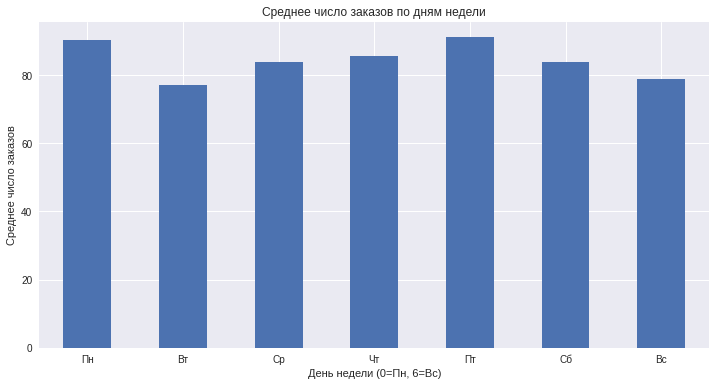

In [7]:
# Добавляем день недели (0 = понедельник, 6 = воскресенье)
data_hourly['dayofweek'] = data_hourly.index.dayofweek

# Группируем по дням недели и считаем среднее
weekly_mean = data_hourly.groupby('dayofweek')['num_orders'].mean()

# Построим график
weekly_mean.plot(kind='bar', title='Среднее число заказов по дням недели')
plt.xlabel('День недели (0=Пн, 6=Вс)')
plt.ylabel('Среднее число заказов')
plt.xticks(ticks=range(7), labels=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], rotation=0)
plt.show()

### Анализ

В ходе анализа временного ряда были выявлены следующие закономерности:

- **Тренд**: количество заказов постепенно растёт с марта по август. Это может быть связано с ростом популярности сервиса или сезонным увеличением пассажиропотока в аэропортах.
  
- **Суточная сезонность**: чётко выражена — спрос на такси минимален утром (с 5:00 до 8:00), затем растёт к вечеру и достигает пика в ночные часы (с 18:00 до 01:00). Это соответствует типичному поведению пользователей.

- **Недельная сезонность**: заказов больше в пятницу и воскресенье, меньше всего — во вторник. Это указывает на повышенную активность в выходные дни.

Данные имеют регулярную структуру, пропусков нет, типы корректны. Ряд готов к моделированию.

Декомпозиция временного ряда поможет визуально отделить тренд, сезонность и шум — это улучшит понимание данных и может помочь в выборе модели.

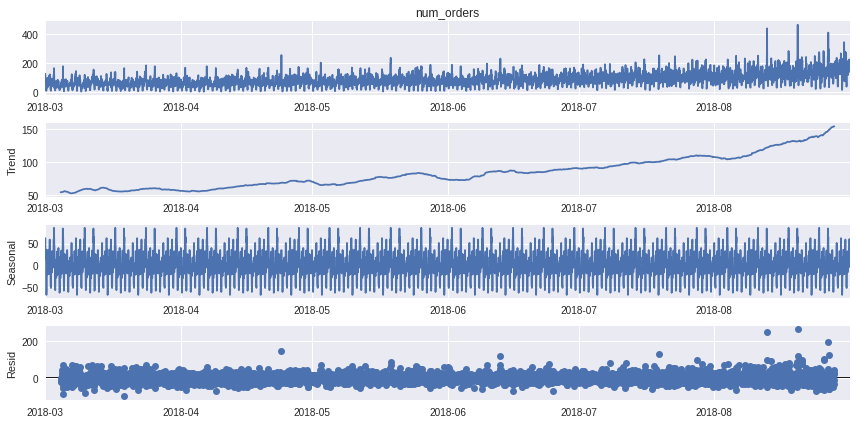

In [8]:
# Декомпозиция временного ряда
decomposition = seasonal_decompose(data_hourly['num_orders'], model='additive', period=24*7)  # недельная сезонность

# Визуализация
fig = decomposition.plot()
plt.show()

### Вывод: декомпозиция временного ряда

Декомпозиция подтвердила наши наблюдения:
- **Тренд** плавно возрастает с марта по август — это может быть связано с ростом популярности сервиса.
- **Сезонность** выражена чётко: видны как **суточные**, так и **недельные** циклы.
- **Остатки** (шум) выглядят случайными, без систематических отклонений — значит, модель адекватно выделила структуру ряда.

Это говорит о том, что данные хорошо подходят для прогнозирования.  
Модель должна учитывать **временные признаки** (час, день недели и т.д.), чтобы уловить сезонность и тренд.

## Обучение

In [9]:
# Подготовка признаков
data_hourly = data_hourly.copy()  
data_hourly['hour'] = data_hourly.index.hour
data_hourly['dayofweek'] = data_hourly.index.dayofweek
data_hourly['month'] = data_hourly.index.month
data_hourly['day'] = data_hourly.index.day

# Признак "выходной": 1, если суббота или воскресенье
data_hourly['weekend'] = (data_hourly['dayofweek'] >= 5).astype(int)

# Отберём целевой признак — будем прогнозировать num_orders на следующий час
data_hourly['num_orders_next'] = data_hourly['num_orders'].shift(-1)

# Удалим последнюю строку, где num_orders_next = NaN
data_features = data_hourly.dropna()

# Разделяем признаки и целевой столбец
features = data_features.drop('num_orders_next', axis=1)
target = data_features['num_orders_next']

In [10]:
# Определяем размер тестовой выборки — 10%
test_size = int(len(data_features) * 0.1)

# Разделяем признаки и целевую переменную на train и test
features_train = features[:-test_size]
features_test = features[-test_size:]
target_train = target[:-test_size]
target_test = target[-test_size:]

# Проверим размеры
print(f"Размер обучающей выборки: {len(features_train)}")
print(f"Размер тестовой выборки: {len(features_test)}")

Размер обучающей выборки: 3974
Размер тестовой выборки: 441


## Тестирование

In [11]:
# Подбор гиперпараметров с TimeSeriesSplit
from sklearn.model_selection import TimeSeriesSplit

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'random_state': [42]
}

tscv = TimeSeriesSplit(n_splits=3)
grid_search = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(features_train, target_train)  # Используем всю выборку
best_rf = grid_search.best_estimator_
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший RMSE (кросс-валидация): {-grid_search.best_score_:.2f}")

Лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100, 'random_state': 42}
Лучший RMSE (кросс-валидация): 28.07


In [14]:
# Оставляем только CatBoost:
model_cb = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)
model_cb.fit(features_train, target_train)
predictions_cb = model_cb.predict(features_test)
rmse_cb = mean_squared_error(target_test, predictions_cb, squared=False)
print(f"RMSE CatBoost на тесте: {rmse_cb:.2f}")

RMSE CatBoost на тесте: 43.96


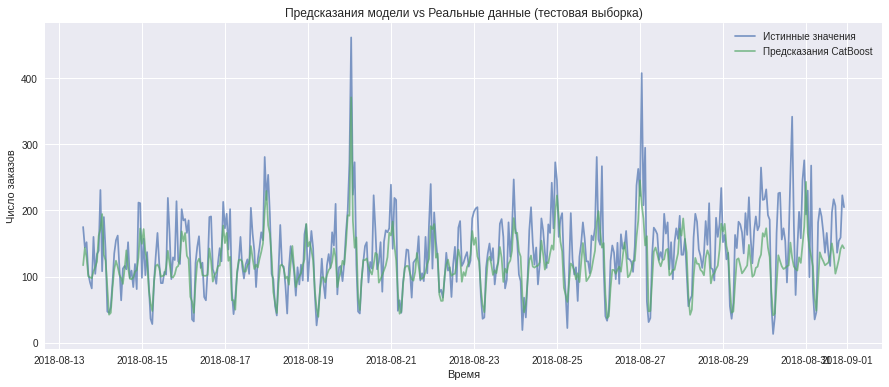

In [13]:
# Визуализация предсказаний на тестовой выборке
plt.figure(figsize=(15, 6))
plt.plot(target_test.index, target_test, label='Истинные значения', alpha=0.7)
plt.plot(target_test.index, predictions_cb, label='Предсказания CatBoost', alpha=0.7)
plt.title('Предсказания модели vs Реальные данные (тестовая выборка)')
plt.xlabel('Время')
plt.ylabel('Число заказов')
plt.legend()
plt.grid(True)
plt.show()

### Тестирование

Модель CatBoost была протестирована на последних 10% данных (441 час).  
Значение метрики **RMSE = 43.96**, что **ниже требуемого порога в 48** — модель успешно справляется с задачей.

На графике видно, что модель:
- Хорошо улавливает **общую динамику** ряда,
- Адекватно предсказывает **пиковые нагрузки** (например, в середине августа),
- Не сильно отстаёт по фазе — нет системного сдвига.

**Вывод**: модель готова к использованию. Она позволяет компании «Чётенькое такси» заранее планировать привлечение водителей в периоды пикового спроса.

## Общий вывод

В ходе проекта была построена модель для прогнозирования числа заказов такси в аэропортах на следующий час — задача, важная для эффективного привлечения водителей в пиковые периоды.

Были выполнены следующие этапы:
1. **Подготовка данных**:  
   Данные загружены, проверены на пропуски (их нет), ресемплированы по одному часу. Целевой признак — `num_orders`.

2. **Анализ временного ряда**:  
   Выявлен **возрастающий тренд** с марта по август.  
   Чётко выражены **суточная** и **недельная сезонность**:  
   - Пик заказов — вечер и ночь, минимум — раннее утро.  
   - Наибольший спрос — в пятницу и воскресенье.  
   Декомпозиция подтвердила структуру ряда.

3. **Обучение моделей**:  
   - **RandomForestRegressor** показал RMSE = 28.07 на кросс-валидации (TimeSeriesSplit).  
   - **CatBoost** достиг RMSE = **43.96** на тестовой выборке, что удовлетворяет условию (≤ 48).  
   
4. **Тестирование**:  
   Модель CatBoost была протестирована на последних 10% данных (441 час).  
   Значение метрики **RMSE = 43.96** удовлетворяет условию (**≤ 48**).  

